## Stereo Rectification

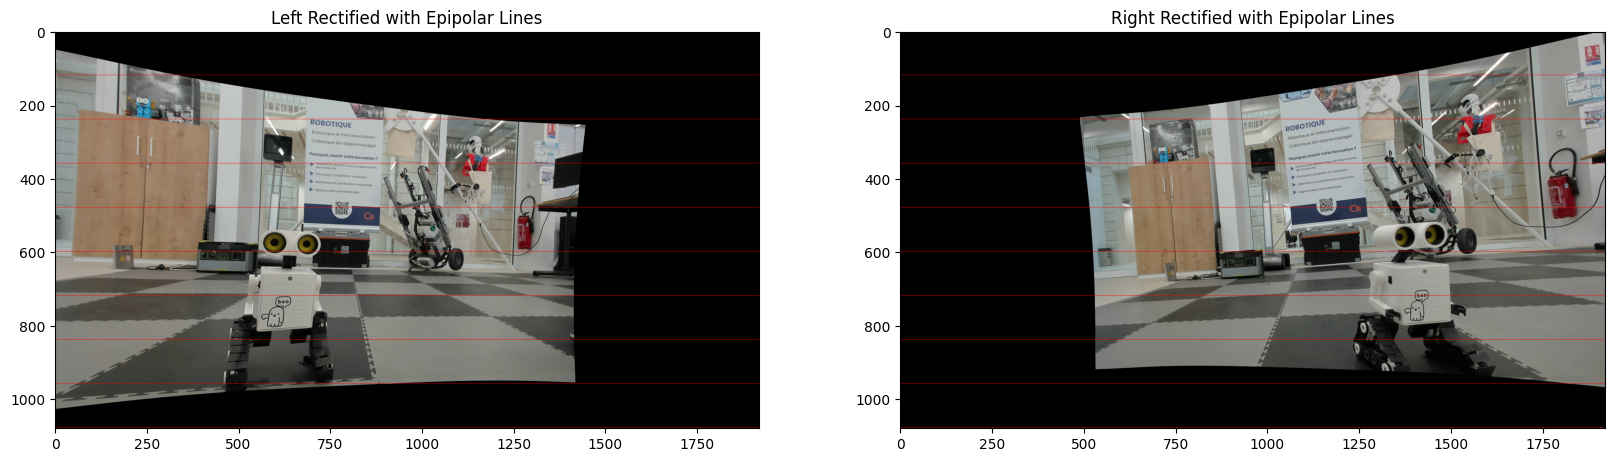

True

In [2]:
# %% [markdown]
# # Stereo Rectification Pipeline
# Applies calibration data to rectify new image pairs

# %%
import numpy as np
import cv2
import matplotlib.pyplot as plt

# %% [markdown]
# ## 1. Load Calibration Data
# Load parameters from previous calibration
CHECKERBOARD = (7, 9)        # Inner corners (columns, rows)

# %%
calib_data = np.load('stereo_calibration.npz')

# Rectification maps
left_map_x = calib_data['left_map_x']
left_map_y = calib_data['left_map_y']
right_map_x = calib_data['right_map_x']
right_map_y = calib_data['right_map_y']

# Camera parameters
Q = calib_data['Q']  # Disparity-to-depth mapping matrix

# %% [markdown]
# ## 2. Load Object Images
# These should be NEW images not used in calibration

# %%
left_img = cv2.imread('extra/left_45.jpg')
right_img = cv2.imread('extra/right_45.jpg')

# Validate image pair
assert left_img.shape == right_img.shape, "Mismatched image dimensions"

# %% [markdown]
# ## 3. Rectification Process
# Apply precomputed remapping

# %%
def rectify_images(left, right):
    """Rectify image pair using calibration maps"""
    rect_left = cv2.remap(left, left_map_x, left_map_y, cv2.INTER_LANCZOS4)
    rect_right = cv2.remap(right, right_map_x, right_map_y, cv2.INTER_LANCZOS4)
    return rect_left, rect_right

rect_left, rect_right = rectify_images(left_img, right_img)

# %% [markdown]
# ## 4. Rectification Validation
# Verify epipolar line alignment

# %%
def plot_epipolar_lines(img1, img2, num_lines=10):
    """Visualize horizontal epipolar lines"""
    h, w = img1.shape[:2]
    y_positions = np.linspace(0, h-1, num_lines, dtype=int)
    
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    
    # Left image lines
    disp_left = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    for y in y_positions:
        cv2.line(disp_left, (0, y), (w-1, y), (255, 0, 0), 1)
    ax[0].imshow(disp_left)
    ax[0].set_title('Left Rectified with Epipolar Lines')
    
    # Right image lines
    disp_right = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    for y in y_positions:
        cv2.line(disp_right, (0, y), (w-1, y), (255, 0, 0), 1)
    ax[1].imshow(disp_right)
    ax[1].set_title('Right Rectified with Epipolar Lines')
    
    plt.show()

# Visualize
plot_epipolar_lines(rect_left, rect_right)

# %% [markdown]
# ## 5. Quantitative Evaluation
# Measure rectification accuracy

# %%
def check_rectification_quality(rect_left, rect_right):
    """Calculate vertical disparity of checkerboard corners"""
    # Find corners in both images
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    
    # Process left
    gray_left = cv2.cvtColor(rect_left, cv2.COLOR_BGR2GRAY)
    ret_l, corners_l = cv2.findChessboardCorners(gray_left, CHECKERBOARD, None)
    if ret_l:
        corners_l = cv2.cornerSubPix(gray_left, corners_l, (11,11), (-1,-1), criteria)
    
    # Process right
    gray_right = cv2.cvtColor(rect_right, cv2.COLOR_BGR2GRAY)
    ret_r, corners_r = cv2.findChessboardCorners(gray_right, CHECKERBOARD, None)
    if ret_r:
        corners_r = cv2.cornerSubPix(gray_right, corners_r, (11,11), (-1,-1), criteria)
    
    if ret_l and ret_r:
        # Calculate vertical differences
        vertical_diffs = np.abs(corners_l[:,0,1] - corners_r[:,0,1])
        avg_diff = np.mean(vertical_diffs)
        max_diff = np.max(vertical_diffs)
        
        print(f"Rectification Quality Metrics:")
        print(f"Average vertical disparity: {avg_diff:.2f} pixels")
        print(f"Maximum vertical disparity: {max_diff:.2f} pixels")
        
        # Plot histogram
        plt.figure()
        plt.hist(vertical_diffs, bins=20)
        plt.xlabel('Vertical Disparity (pixels)')
        plt.ylabel('Frequency')
        plt.title('Epipolar Alignment Accuracy')
        plt.show()
    else:
        print("Warning: Checkerboard not found in rectified images")

check_rectification_quality(rect_left, rect_right)

# %% [markdown]
# ## 6. Save Rectified Images
# For downstream processing

# %%
cv2.imwrite('rectified_left.jpg', rect_left)
cv2.imwrite('rectified_right.jpg', rect_right)